# **Transformace dat**
### *Příprava datasetu Titanic v Pythonu a Orange*

**Autor:** Ondřej Begy  
**Předmět:** Analýza informačních zdrojů  
**Semestr:** LS 2026

---

## **Metodický rámec**
**Cíl**: Provést řízenou přípravu dat před modelováním s důrazem na škálování, práci s chybějícími hodnotami, sampling, encoding a binning

**Fáze analytického procesu:**
1. **Programová transformace v Pythonu** - implementace úloh 1 až 5 se striktní kontrolou `fit()` a `transform()`
2. **Vizuální pipeline v Orange** - orientační workflow pro preprocessing, sampling a encoding
3. **Verifikace a syntéza** - kontrola distribucí po transformaci a interpretace dopadů na data

### ***Načtení knihoven a nastavení prostředí***

In [11]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, RobustScaler, StandardScaler, OneHotEncoder

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Všechny knihovny byly úspěšně načteny')

Všechny knihovny byly úspěšně načteny


In [12]:
# Načtení datasetu Titanic
base_df = sns.load_dataset('titanic')

# Odstranění sloupců, které nejsou pro preprocessing potřeba
raw_df = base_df.drop(columns=['alive', 'class', 'who', 'adult_male', 'deck', 'embark_town']).copy()

# Export pro Orange a další zpracování
raw_df.to_csv('titanic_raw.csv', index=False)

# Jednotná trénovací/testovací sada pro úlohy, kde je důležité zabránit leakage
train_df, test_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['survived'])

print('Dataset úspěšně načten!')
print(f'Rozměry matice: {raw_df.shape}')
print(f'Počet řádků: {raw_df.shape[0]}')
print(f'Počet sloupců: {raw_df.shape[1]}')
print('\nPrvních 5 řádků datasetu:')
display(raw_df.head())

print('\nRozdělení train/test:')
print(f'Train: {train_df.shape}')
print(f'Test: {test_df.shape}')

Dataset úspěšně načten!
Rozměry matice: (891, 9)
Počet řádků: 891
Počet sloupců: 9

Prvních 5 řádků datasetu:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True



Rozdělení train/test:
Train: (712, 9)
Test: (179, 9)


---

## **1. Škálování příznaků a imunita vůči outlierům**

**Zadání:**
1. Rozdělte data na trénovací a testovací část v poměru 80 : 20.
2. Aplikujte `MinMaxScaler`, `StandardScaler` a `RobustScaler` na sloupec `fare`.
3. Dodržte pravidlo No Data Leakage - parametry škálovačů se smějí učit pouze z trénovací množiny.
4. Vykreslete detailní distribuci přeskalovaných hodnot pro běžné jízdenky v rozsahu od -1 do +2 a určete, který škálovač zachová vnitřní rozlišení dat nejlépe.

### ***Python Stack: Implementace***

In [13]:
### 1.1 Škálování sloupce fare bez data leakage

print('=' * 70)
print('ŠKÁLOVÁNÍ PŘÍZNAKU FARE')
print('=' * 70)

fare_train = train_df[['fare']].copy()
fare_test = test_df[['fare']].copy()

scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

scaled_train = {}
scaled_test = {}
scaler_summary = []

for name, scaler in scalers.items():
    scaled_train[name] = scaler.fit_transform(fare_train)
    scaled_test[name] = scaler.transform(fare_test)

    train_values = scaled_train[name].ravel()
    test_values = scaled_test[name].ravel()

    scaler_summary.append({
        'Scaler': name,
        'Train mean': np.mean(train_values),
        'Train std': np.std(train_values),
        'Train min': np.min(train_values),
        'Train max': np.max(train_values),
        'Test mean': np.mean(test_values),
        'Test std': np.std(test_values)
    })

summary_df = pd.DataFrame(scaler_summary)
print('\nPorovnání základních charakteristik po škálování:')
display(summary_df.round(4))

print('\nParametry škálovačů natrénované pouze na train části:')
for name, scaler in scalers.items():
    print(f'\n{name}:')
    if hasattr(scaler, 'center_'):
        print(f'  center_: {float(scaler.center_[0]):.4f}')
    if hasattr(scaler, 'scale_'):
        print(f'  scale_: {float(scaler.scale_[0]):.4f}')
    if hasattr(scaler, 'data_min_'):
        print(f'  data_min_: {float(scaler.data_min_[0]):.4f}')
    if hasattr(scaler, 'data_max_'):
        print(f'  data_max_: {float(scaler.data_max_[0]):.4f}')

ŠKÁLOVÁNÍ PŘÍZNAKU FARE

Porovnání základních charakteristik po škálování:


,Scaler,Train mean,Train std,Train min,Train max,Test mean,Test std
0,MinMaxScaler,0.0621,0.0937,0.0000,1.0000,0.0658,0.1087
1,StandardScaler,-0.0000,1.0000,-0.6626,10.0053,0.0398,1.1595
2,RobustScaler,0.7516,2.0786,-0.6256,21.5491,0.8344,2.4103



Parametry škálovačů natrénované pouze na train části:

MinMaxScaler:
  scale_: 0.0020
  data_min_: 0.0000
  data_max_: 512.3292

StandardScaler:
  scale_: 48.0253

RobustScaler:
  center_: 14.4542
  scale_: 23.1042


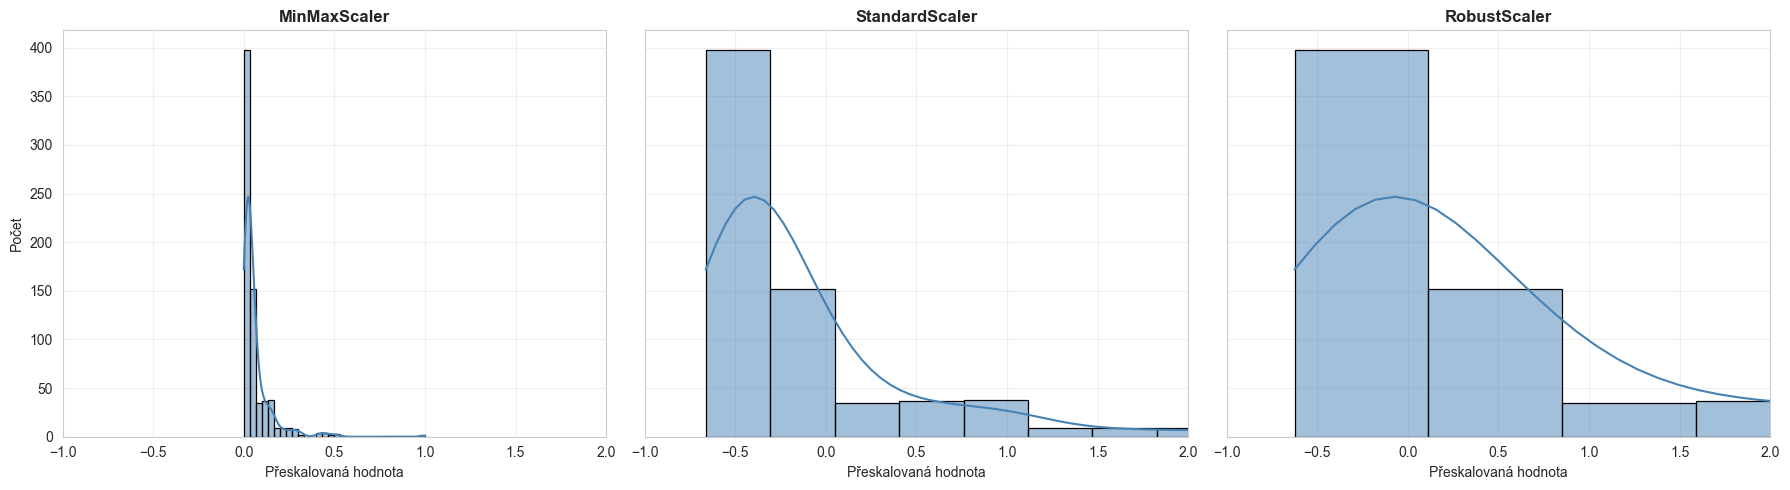

Rozsah -1 až +2 odpovídá běžným hodnotám většiny pasažérů; extrémní hodnoty jsou mimo zoom.
RobustScaler obvykle zachová největší vnitřní rozlišení, protože používá medián a IQR místo min/max nebo průměru a směrodatné odchylky.


In [14]:
### 1.2 Detailní distribuce přeskalovaných hodnot v rozsahu -1 až +2

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, values) in zip(axes, scaled_train.items()):
    sns.histplot(values.ravel(), bins=30, kde=True, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(name, fontweight='bold')
    ax.set_xlim(-1, 2)
    ax.set_xlabel('Přeskalovaná hodnota')
    ax.set_ylabel('Počet')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Rozsah -1 až +2 odpovídá běžným hodnotám většiny pasažérů; extrémní hodnoty jsou mimo zoom.')
print('RobustScaler obvykle zachová největší vnitřní rozlišení, protože používá medián a IQR místo min/max nebo průměru a směrodatné odchylky.')

### ***Závěr 1. úlohy***

**Klíčové zjištění:**
- `MinMaxScaler` silně stlačuje běžné hodnoty kvůli extrémním outlierům ve sloupci `fare`
- `StandardScaler` je stabilnější, ale pořád je citlivý na extrémy v distribuci
- `RobustScaler` zachovává nejlepší vnitřní rozlišení běžných jízdenek, protože je založený na mediánu a mezikvartilovém rozpětí
- Parametry škálovačů byly učené pouze na trénovací množině, takže nedošlo k `data leakage`

---

## **2. Strategie filtrace a ošetření chybějících hodnot**

**Zadání:**
1. Zjistěte přesný podíl chybějících hodnot u všech proměnných v trénovací množině.
2. Automaticky odstraňte sloupce s více než 70 % chybějících dat a určete, který sloupec kritérium splnil.
3. U sloupce `embarked` odstraňte pouze řádky s chybějící hodnotou.
4. Rozhodněte, zda je `age` spíše MAR a `deck` MNAR, a stručně zdůvodněte proč.

### ***Python Stack: Implementace***

In [15]:
### 2.1 Analýza chybějících hodnot v trénovací množině

print('=' * 70)
print('ANALÝZA CHYBĚJÍCÍCH HODNOT')
print('=' * 70)

# Pro tuto úlohu používáme původní Titanic data včetně sloupce deck
missing_df = base_df.copy()
missing_train_df, missing_test_df = train_test_split(
    missing_df,
    test_size=0.2,
    random_state=42,
    stratify=missing_df['survived']
)

missing_summary = pd.DataFrame({
    'Sloupec': missing_train_df.columns,
    'Chybějící': missing_train_df.isnull().sum().values,
    'Podíl chybějících (%)': (missing_train_df.isnull().mean().values * 100)
})

missing_summary = missing_summary.sort_values('Podíl chybějících (%)', ascending=False)
print('\nPodíl chybějících hodnot v trénovací množině:')
display(missing_summary.round(2))

print(f"\nCelkový počet chybějících hodnot v trénovací množině: {missing_train_df.isnull().sum().sum()}")
print(f"Podíl chybějících buněk v trénovací množině: {missing_train_df.isnull().mean().mean() * 100:.2f}%")

ANALÝZA CHYBĚJÍCÍCH HODNOT

Podíl chybějících hodnot v trénovací množině:


,Sloupec,Chybějící,Podíl chybějících (%)
11,deck,553,77.67
3,age,137,19.24
7,embarked,2,0.28
12,embark_town,2,0.28
2,sex,0,0.00
1,pclass,0,0.00
0,survived,0,0.00
6,fare,0,0.00
5,parch,0,0.00
4,sibsp,0,0.00



Celkový počet chybějících hodnot v trénovací množině: 694
Podíl chybějících buněk v trénovací množině: 6.50%


In [16]:
### 2.2 Filtrace sloupců a ošetření embarked

print('\n' + '=' * 70)
print('FILTRACE CHYBĚJÍCÍCH HODNOT')
print('=' * 70)

threshold = len(missing_train_df) * 0.3
filtered_train_df = missing_train_df.dropna(axis=1, thresh=threshold)
removed_columns = sorted(set(missing_train_df.columns) - set(filtered_train_df.columns))

print(f'Prahová hodnota pro zachování sloupce: {threshold:.0f} ne-chybějících hodnot')
print(f'Počet sloupců před filtrem: {missing_train_df.shape[1]}')
print(f'Počet sloupců po filtru: {filtered_train_df.shape[1]}')
print(f'Odstraněné sloupce: {removed_columns}')

train_no_embarked_missing = missing_train_df.dropna(subset=['embarked']).copy()
print(f"\nŘádky po odstranění pouze chybějícího embarked: {len(train_no_embarked_missing)}")
print(f"Odstraněno řádků: {len(missing_train_df) - len(train_no_embarked_missing)}")

print('\nKontrola zbylých chybějících hodnot v selected sloupcích:')
print(train_no_embarked_missing[['age', 'deck']].isnull().sum())


FILTRACE CHYBĚJÍCÍCH HODNOT
Prahová hodnota pro zachování sloupce: 214 ne-chybějících hodnot
Počet sloupců před filtrem: 15
Počet sloupců po filtru: 14
Odstraněné sloupce: ['deck']

Řádky po odstranění pouze chybějícího embarked: 710
Odstraněno řádků: 2

Kontrola zbylých chybějících hodnot v selected sloupcích:
age     137
deck    553
dtype: int64


In [17]:
### 2.3 MAR vs. MNAR interpretace

print('\n' + '=' * 70)
print('INTERPRETACE MISSINGNESS')
print('=' * 70)

print('AGE: spíše MAR')
print('  - Chybějící věk může být vysvětlen jinými proměnnými, například třídou, pohlavím nebo typem pasažéra.')
print('  - Hodnoty tedy mohou chybět podmíněně na pozorovaných datech, ne nutně zcela náhodně.')

print('\nDECK: MNAR')
print('  - Chybějící deck je velmi silně systémové a souvisí s tím, zda byla kajuta vůbec evidována.')
print('  - Chybějící informace je navázaná na samotný proces sběru dat a sociální třídu.')
print('  - Proto jde o typický kandidát na MNAR.')



INTERPRETACE MISSINGNESS
AGE: spíše MAR
  - Chybějící věk může být vysvětlen jinými proměnnými, například třídou, pohlavím nebo typem pasažéra.
  - Hodnoty tedy mohou chybět podmíněně na pozorovaných datech, ne nutně zcela náhodně.

DECK: MNAR
  - Chybějící deck je velmi silně systémové a souvisí s tím, zda byla kajuta vůbec evidována.
  - Chybějící informace je navázaná na samotný proces sběru dat a sociální třídu.
  - Proto jde o typický kandidát na MNAR.


### ***Závěr 2. úlohy***

**Klíčové zjištění:**
- Sloupec `deck` překročil práh 70 % chybějících hodnot a byl proto odstraněn
- Sloupec `embarked` byl ošetřen cíleně na úrovni konkrétních řádků
- `age` je vhodné chápat jako spíše `MAR`, protože jeho absence může souviset s jinými pozorovanými proměnnými
- `deck` je výrazně `MNAR`, protože chybění je strukturální a svázané se způsobem evidence

---

## **3. Teorie vzorkování a reprezentativnost**

**Zadání:**
1. Definujte globální proměnnou `size = 100`.
2. Nasimulujte náhodný výběr bez vracení i s vracením a u verze s vracením určete počet duplicit.
3. Aplikujte stratifikovaný výběr vzhledem k cílové proměnné `survived`.
4. Porovnejte výsledné distribuce tříd napříč metodami.

### ***Python Stack: Implementace***

In [18]:
### 3.1 Náhodný výběr bez vracení, s vracením a stratifikace

print('=' * 70)
print('TEORIE VZORKOVÁNÍ A REPREZENTATIVNOSTI')
print('=' * 70)

size = 100

s_wor = raw_df.sample(n=size, replace=False, random_state=42)
s_wr = raw_df.sample(n=size, replace=True, random_state=42)
_, s_strat = train_test_split(raw_df, test_size=size, stratify=raw_df['survived'], random_state=42)

duplicates = size - s_wr.index.nunique()

print(f'Požadovaná velikost vzorku: {size}')
print(f'SRSWOR velikost: {len(s_wor)}')
print(f'SRSWR velikost: {len(s_wr)}')
print(f'Počet duplicit ve vzorku s vracením: {duplicates}')
print(f'Stratifikovaný výběr velikost: {len(s_strat)}')

samples = {
    'SRSWOR': s_wor,
    'SRSWR': s_wr,
    'Stratifikace': s_strat
}

comparison_rows = []
for name, sample in samples.items():
    survived_share = sample['survived'].value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100
    comparison_rows.append({
        'Metoda': name,
        'Nepřežil (%)': survived_share.loc[0],
        'Přežil (%)': survived_share.loc[1]
    })

sample_comparison = pd.DataFrame(comparison_rows)
print('\nPorovnání distribuce cílové proměnné:')
display(sample_comparison.round(2))

print('\nZákladní třídy v populaci:')
print(raw_df['survived'].value_counts(normalize=True).sort_index().mul(100).round(2))

print('\nZákladní třídy v jednotlivých vzorcích:')
for name, sample in samples.items():
    print(f'\n{name}:')
    print(sample['survived'].value_counts(normalize=True).sort_index().mul(100).round(2))

TEORIE VZORKOVÁNÍ A REPREZENTATIVNOSTI
Požadovaná velikost vzorku: 100
SRSWOR velikost: 100
SRSWR velikost: 100
Počet duplicit ve vzorku s vracením: 5
Stratifikovaný výběr velikost: 100

Porovnání distribuce cílové proměnné:


,Metoda,Nepřežil (%),Přežil (%)
0,SRSWOR,60.0,40.0
1,SRSWR,67.0,33.0
2,Stratifikace,62.0,38.0



Základní třídy v populaci:
survived
0    61.62
1    38.38
Name: proportion, dtype: float64

Základní třídy v jednotlivých vzorcích:

SRSWOR:
survived
0    60.0
1    40.0
Name: proportion, dtype: float64

SRSWR:
survived
0    67.0
1    33.0
Name: proportion, dtype: float64

Stratifikace:
survived
0    62.0
1    38.0
Name: proportion, dtype: float64


### ***Závěr 3. úlohy***

**Klíčové zjištění:**
- SRSWOR i SRSWR vytvářejí jiné malé vzorky pokaždé, ale bez záruky zachování třídního poměru
- Stratifikace drží poměr `survived` nejblíže původní populaci
- Výběr s vracením obsahuje duplicity, což snižuje informační diverzitu vzorku
- Pro následné modelování je stratifikace stabilnější než prostá náhoda

---

## **4. Transformace kategorií**

**Zadání:**
1. Rozlište charakter proměnných `sex` a `pclass`.
2. Aplikujte `OneHotEncoder` na `embarked`.
3. Aplikujte `OrdinalEncoder` na `pclass` při zachování logiky tříd.
4. Vysvětlete riziko, pokud by byl `embarked` zakódován jen jako 0, 1, 2.

### ***Python Stack: Implementace***

In [19]:
### 4.1 One-Hot Encoding pro embarked a Ordinal Encoding pro pclass

print('=' * 70)
print('TRANSFORMACE KATEGORIÍ')
print('=' * 70)

encoding_df = raw_df.dropna(subset=['embarked']).copy()

# One-Hot Encoding pro nominální proměnnou embarked
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
embarked_encoded = ohe.fit_transform(encoding_df[['embarked']])
embarked_columns = ohe.get_feature_names_out(['embarked'])
embarked_encoded_df = pd.DataFrame(embarked_encoded, columns=embarked_columns, index=encoding_df.index)

print('\nOne-Hot Encoding pro embarked:')
print(f'Původní počet kategorií: {len(ohe.categories_[0])}')
print(f'Vzniklé sloupce: {list(embarked_columns)}')
display(embarked_encoded_df.head())

# Ordinal Encoding pro pclass se zachováním logiky tříd
pclass_text = raw_df[['pclass']].astype(str)
oe = OrdinalEncoder(categories=[['3', '2', '1']])
pclass_encoded = oe.fit_transform(pclass_text)
pclass_encoded_df = pd.DataFrame({
    'pclass': raw_df['pclass'],
    'pclass_encoded': pclass_encoded.astype(int).ravel()
})

print('\nOrdinal Encoding pro pclass:')
display(pclass_encoded_df.drop_duplicates().sort_values('pclass'))

print('\nKontrola logiky: vyšší společenská třída dostává vyšší číselnou reprezentaci v zakódované podobě.')

TRANSFORMACE KATEGORIÍ

One-Hot Encoding pro embarked:
Původní počet kategorií: 3
Vzniklé sloupce: ['embarked_C', 'embarked_Q', 'embarked_S']


,embarked_C,embarked_Q,embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0



Ordinal Encoding pro pclass:


,pclass,pclass_encoded
1,1,2
9,2,1
0,3,0



Kontrola logiky: vyšší společenská třída dostává vyšší číselnou reprezentaci v zakódované podobě.


### ***Závěr 4. úlohy***

**Klíčové zjištění:**
- `embarked` je nominální proměnná, proto je vhodný `OneHotEncoder`
- `pclass` je ordinální proměnná, proto je vhodný `OrdinalEncoder` se zachováním pořadí tříd
- Přímé zakódování `embarked` jako 0, 1, 2 by vneslo falešnou ordinální informaci
- Taková chyba by mohla modelu sugerovat vztah mezi přístavy, který ve skutečnosti neexistuje

---

## **5. Diskretizace, vyhlazování a tvorba příznaků**

**Zadání:**
1. Rozdělte `age` na 3 přihrádky metodou equal-width a equal-frequency.
2. Proveďte vyhlazení dat nahrazením věku průměrem jeho přihrádky.
3. Vytvořte příznak `family_size = sibsp + parch + 1`.
4. Vizualizujte dělící čáry obou metod binningu ve scatter plotu.

### ***Python Stack: Implementace***

DISKRETIZACE, VYHLAZOVÁNÍ A TVORBA PŘÍZNAKŮ

Hranice equal-width binningu:
[ 0.34 26.95 53.47 80.  ]

Hranice equal-frequency binningu:
[ 0.42 23.   34.   80.  ]

Frekvence tříd přiřazených do binů:

Equal-width:
age_width
(0.339, 26.947]     319
(26.947, 53.473]    345
(53.473, 80.0]       50
NaN                 177
Name: count, dtype: int64

Equal-frequency:
age_freq
(0.419, 23.0]    246
(23.0, 34.0]     232
(34.0, 80.0]     236
NaN              177
Name: count, dtype: int64


,age,age_width,age_freq,age_smoothed,family_size
0,22.0,"(0.339, 26.947]","(0.419, 23.0]",17.364169,2
1,38.0,"(26.947, 53.473]","(34.0, 80.0]",36.608696,2
2,26.0,"(0.339, 26.947]","(23.0, 34.0]",17.364169,1
3,35.0,"(26.947, 53.473]","(34.0, 80.0]",36.608696,2
4,35.0,"(26.947, 53.473]","(34.0, 80.0]",36.608696,1
5,NaN,NaN,NaN,NaN,1
6,54.0,"(53.473, 80.0]","(34.0, 80.0]",60.720000,1
7,2.0,"(0.339, 26.947]","(0.419, 23.0]",17.364169,5
8,27.0,"(26.947, 53.473]","(23.0, 34.0]",36.608696,3
9,14.0,"(0.339, 26.947]","(0.419, 23.0]",17.364169,2


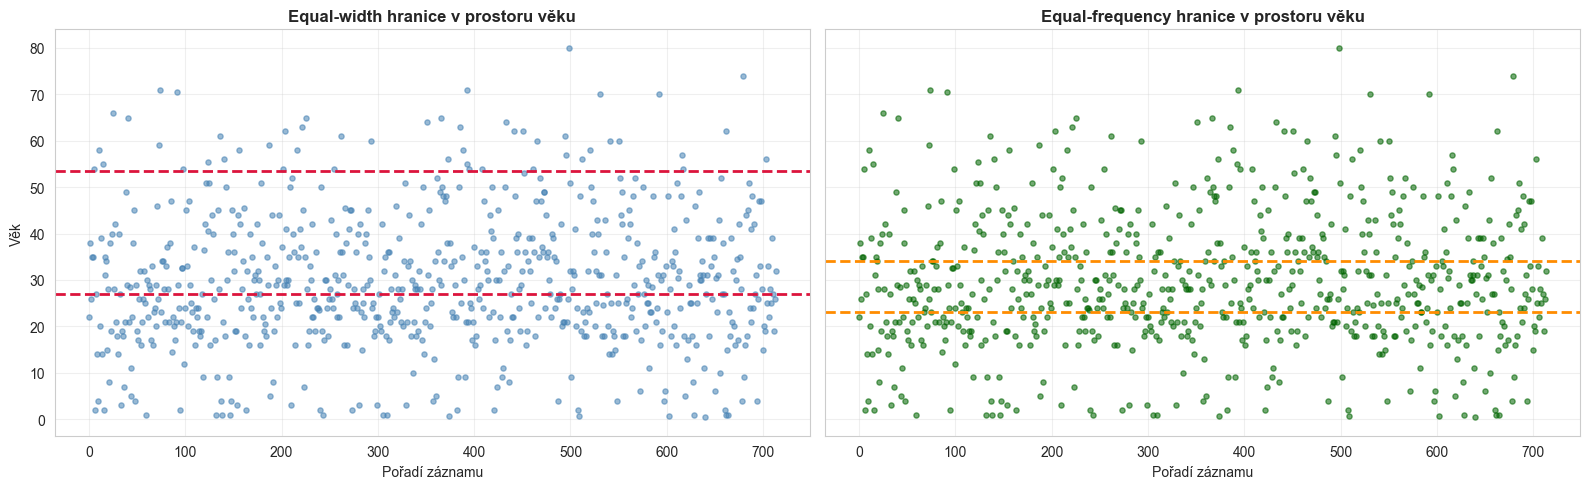


Finální pracovní dataset exportován: titanic_feature_engineered.csv


In [20]:
### 5.1 Binning, smoothing a feature construction

print('=' * 70)
print('DISKRETIZACE, VYHLAZOVÁNÍ A TVORBA PŘÍZNAKŮ')
print('=' * 70)

feature_df = raw_df.copy()
age_non_null = feature_df['age'].dropna()

# Equal-width a equal-frequency hranice
_, width_bins = pd.cut(age_non_null, bins=3, retbins=True, include_lowest=True)
_, freq_bins = pd.qcut(age_non_null, q=3, retbins=True, duplicates='drop')

feature_df['age_width'] = pd.cut(feature_df['age'], bins=width_bins, include_lowest=True)
feature_df['age_freq'] = pd.cut(feature_df['age'], bins=freq_bins, include_lowest=True)
feature_df['age_smoothed'] = feature_df.groupby('age_width')['age'].transform('mean')
feature_df['family_size'] = feature_df['sibsp'] + feature_df['parch'] + 1

print('\nHranice equal-width binningu:')
print(np.round(width_bins, 2))
print('\nHranice equal-frequency binningu:')
print(np.round(freq_bins, 2))

print('\nFrekvence tříd přiřazených do binů:')
print('\nEqual-width:')
print(feature_df['age_width'].value_counts(dropna=False).sort_index())
print('\nEqual-frequency:')
print(feature_df['age_freq'].value_counts(dropna=False).sort_index())

display(feature_df[['age', 'age_width', 'age_freq', 'age_smoothed', 'family_size']].head(10))

# Scatter plot s dělícími čarami
valid_age = feature_df.dropna(subset=['age']).reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

axes[0].scatter(valid_age.index, valid_age['age'], s=14, alpha=0.55, color='steelblue')
for boundary in width_bins[1:-1]:
    axes[0].axhline(boundary, color='crimson', linestyle='--', linewidth=2)
axes[0].set_title('Equal-width hranice v prostoru věku', fontweight='bold')
axes[0].set_xlabel('Pořadí záznamu')
axes[0].set_ylabel('Věk')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(valid_age.index, valid_age['age'], s=14, alpha=0.55, color='darkgreen')
for boundary in freq_bins[1:-1]:
    axes[1].axhline(boundary, color='darkorange', linestyle='--', linewidth=2)
axes[1].set_title('Equal-frequency hranice v prostoru věku', fontweight='bold')
axes[1].set_xlabel('Pořadí záznamu')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Export finálního pracovního datasetu
feature_df.to_csv('titanic_feature_engineered.csv', index=False)
print('\nFinální pracovní dataset exportován: titanic_feature_engineered.csv')

### ***Závěr 5. úlohy***

**Klíčové zjištění:**
- `Equal-width` rozděluje věk podle stejné šířky intervalů, takže může přehlcovat husté části distribuce
- `Equal-frequency` rozděluje data tak, aby v každém binu bylo přibližně stejné množství záznamů
- Vyhlazení pomocí průměru binu snižuje šum a nahrazuje surový věk reprezentativní hodnotou
- `family_size = sibsp + parch + 1` je smysluplný inženýrský příznak, protože zachycuje rodinný kontext pasažéra

---

## **Shrnutí - Interpretace a závěry**

### ***Syntéza poznatků z celého workshopu***

- Dataset byl připraven pro další modelování bez zbytečného data leakage
- `fare` je citlivý na outliery, proto je pro něj nejrobustnější škálování přes `RobustScaler`
- `deck` je silně problematický kvůli MNAR a je vhodný spíše k odstranění
- Stratifikované vzorkování udržuje stabilní strukturu cílové proměnné
- `embarked` je nutné kódovat jako nominální kategorii, zatímco `pclass` zachovává ordinální logiku
- Binning a feature construction přidávají do dat reprezentaci, která je často lépe použitelná pro modely i vizualizační nástroje

### ***Závěrečný audit***

Pracovní dataset je nyní připravený pro další fázi strojového učení i pro Orange workflow. Vznikly soubory `titanic_raw.csv` a `titanic_feature_engineered.csv`, které lze použít jako vstupní data pro následné experimenty.